Name: Bill Amegah

Roll No: 10022200079

Course: Neural Networks 

# Assignment 1: Neural Networks from Scratch - MNIST Classification

In this assignment, you will implement a simple feedforward neural network (multilayer perceptron) from scratch using only NumPy.
This exercise will help you connect the theory we covered in class (vectors, matrices, derivatives, gradients, loss functions, backpropagation, and regularization) with a real-world dataset.

#### Learning Objectives
1. Represent inputs, weights, and activations as vectors, matrices, and tensors.

2. Implement forward propagation through linear layers and activation functions.

3. Compute the Mean Squared Error (MSE) loss function.

4. Derive and implement gradients using backpropagation.

5. Train a neural network using gradient descent.

6. Apply regularization to reduce overfitting.

7. Evaluate and compare predictions against true labels.

#### Dataset
We will use the MNIST dataset, a benchmark dataset of 70,000 images of handwritten digits (0–9).

- Each image is 28 × 28 pixels (flattened into 784 features).

- Labels are integers from 0–9.

- Pixel values range from 0–255. We normalize them to [0,1] for stable training.



#### Import libraries, Load and Preprocess Data

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

In [2]:
# Load and preprocess the dataset

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

# Normalize pixel values to [0,1]
# Explanation: MNIST images are grayscale, pixel values range 0–255. 
# Dividing by 255 rescales values to [0,1], which stabilizes training 
# (prevents large gradients and makes learning faster).
X = X / 255.0  

# Convert labels to integers
y = y.astype(int).reshape(-1, 1)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False, categories="auto")
y_onehot = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Print first 5 samples
print("First 5 samples:")
print("X_train[0:5]:", X_train[:5])
print("y_train[0:5]:", np.argmax(y_train[:5], axis=1))

First 5 samples:
X_train[0:5]: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
y_train[0:5]: [5 4 8 0 2]


#### Define the Functions

In [3]:

#Initialize weights.
# - Small random numbers break symmetry (if all weights = 0, neurons learn the same thing).
# - Scaling with sqrt(1/n) keeps variance stable across layers.
def init_weights(input_size, hidden_size, output_size):
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1. / input_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1. / hidden_size)
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2

# Activation functions
def relu(Z): return np.maximum(0, Z)
def relu_derivative(Z): return (Z > 0).astype(float)
def softmax(Z): 
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / expZ.sum(axis=1, keepdims=True)

# Loss function: Mean Squared Error (MSE)
def mse_loss(y_true, y_pred):
    # Calculate the mean squared error between true and predicted values
    # This measures how far off our predictions are from the actual labels
    return np.mean((y_true - y_pred) ** 2)

# Accuracy metric
def accuracy(y_true, y_pred):
    return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))


In [4]:
# Forward and backward pass
def forward_pass(X, W1, b1, W2, b2):
    # Linear -> ReLU -> Linear -> Softmax
    # First layer: X @ W1 + b1
    Z1 = X @ W1 + b1
    # Apply ReLU activation
    A1 = relu(Z1)
    # Second layer: A1 @ W2 + b2
    Z2 = A1 @ W2 + b2
    # Apply softmax to get probabilities
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2


def backward_pass(X, y, Z1, A1, A2, W2):
    m = X.shape[0]
    # Gradient for MSE Loss
    # dA2 is the gradient of the loss with respect to the output
    dA2 = 2 * (A2 - y) / m  # Derivative of MSE wrt A2
    # dZ2 is the gradient after softmax (approximation for MSE)
    dZ2 = dA2 * A2 * (1 - A2)
    # dW2 and db2 are gradients for W2 and b2
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    # dA1 is the gradient flowing back to the hidden layer
    dA1 = dZ2 @ W2.T
    # dZ1 is the gradient after ReLU
    dZ1 = dA1 * relu_derivative(Z1)
    # dW1 and db1 are gradients for W1 and b1
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2


In [5]:
# Training function
def train_nn(X_train, y_train, X_test, y_test, hidden_size=128, epochs=50, lr=0.01, reg_lambda=0.0001):
    input_size = X_train.shape[1]
    output_size = y_train.shape[1]

    # Initialize weights with He Initialization
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
    b2 = np.zeros((1, output_size))

    train_losses, test_losses, train_accs, test_accs = [], [], [], []

    for epoch in range(epochs):
        # Forward pass
        Z1, A1, Z2, A2 = forward_pass(X_train, W1, b1, W2, b2)
        loss = -np.mean(np.sum(y_train * np.log(A2 + 1e-8), axis=1)) + reg_lambda * (np.sum(W1**2) + np.sum(W2**2))
        acc = accuracy(y_train, A2)

        # Backward pass
        m = X_train.shape[0]
        dZ2 = A2 - y_train
        dW2 = A1.T @ dZ2 / m + reg_lambda * W2
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = X_train.T @ dZ1 / m + reg_lambda * W1
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Update weights
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        # Validation
        _, _, _, A2_test = forward_pass(X_test, W1, b1, W2, b2)
        test_loss = -np.mean(np.sum(y_test * np.log(A2_test + 1e-8), axis=1))
        test_acc = accuracy(y_test, A2_test)

        # Store metrics
        train_losses.append(loss)
        test_losses.append(test_loss)
        train_accs.append(acc)
        test_accs.append(test_acc)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f} - Train Acc: {acc:.4f} - Test Acc: {test_acc:.4f}")

    return W1, b1, W2, b2, train_losses, test_losses, train_accs, test_accs

#### Run Training

In [6]:
# Call the training function with the required arguments
# This will train the neural network and return the weights and metrics
W1, b1, W2, b2, train_losses, test_losses, train_accs, test_accs = train_nn(
    X_train, y_train, X_test, y_test,
    hidden_size=128, epochs=50, lr=0.01, reg_lambda=0.0001
)

Epoch 1/50 - Loss: 2.4303 - Train Acc: 0.0714 - Test Acc: 0.0759
Epoch 2/50 - Loss: 2.4164 - Train Acc: 0.0767 - Test Acc: 0.0804
Epoch 3/50 - Loss: 2.4029 - Train Acc: 0.0815 - Test Acc: 0.0856
Epoch 4/50 - Loss: 2.3898 - Train Acc: 0.0871 - Test Acc: 0.0913
Epoch 5/50 - Loss: 2.3771 - Train Acc: 0.0931 - Test Acc: 0.0972
Epoch 6/50 - Loss: 2.3646 - Train Acc: 0.0998 - Test Acc: 0.1019
Epoch 7/50 - Loss: 2.3524 - Train Acc: 0.1062 - Test Acc: 0.1087
Epoch 8/50 - Loss: 2.3405 - Train Acc: 0.1132 - Test Acc: 0.1151
Epoch 9/50 - Loss: 2.3288 - Train Acc: 0.1208 - Test Acc: 0.1229
Epoch 10/50 - Loss: 2.3174 - Train Acc: 0.1284 - Test Acc: 0.1309
Epoch 11/50 - Loss: 2.3061 - Train Acc: 0.1357 - Test Acc: 0.1394
Epoch 12/50 - Loss: 2.2950 - Train Acc: 0.1433 - Test Acc: 0.1474
Epoch 13/50 - Loss: 2.2841 - Train Acc: 0.1508 - Test Acc: 0.1554
Epoch 14/50 - Loss: 2.2733 - Train Acc: 0.1590 - Test Acc: 0.1630
Epoch 15/50 - Loss: 2.2627 - Train Acc: 0.1674 - Test Acc: 0.1701
Epoch 16/50 - Loss:

#### Plot Results

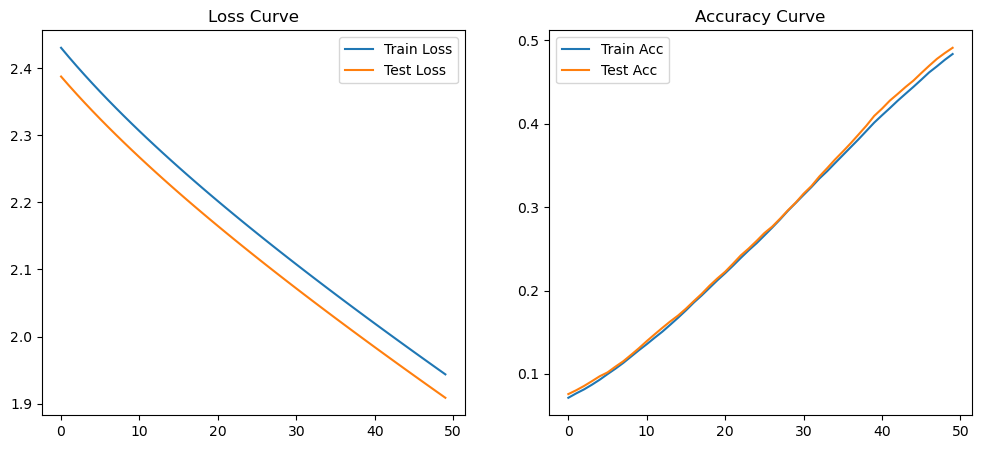

In [7]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(test_accs, label="Test Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()